In [31]:
import json
import numpy as np
from pathlib import Path
from typing import Iterable
import matplotlib.pyplot as plt

In [32]:
def plot_confusion_matrix_binary(
    llm: Iterable[int | bool],
    human: Iterable[int | bool],
    title: str = "Confusion Matrix (LLM vs Human)",
    save_path: str | None = None,
) -> dict:
    """
    Compute and plot a confusion matrix for binary labels with FRACTIONS shown.

    Normalization:
      - Each cell shows fraction over ALL samples.
      - Also shows raw count in parentheses.

    Rows = Human labels (0, 1)
    Cols = LLM labels   (0, 1)

    Returns:
      dict with counts: TP, TN, FP, FN
    """
    llm = list(llm)
    human = list(human)

    if len(llm) != len(human):
        raise ValueError("Input arrays must have the same length.")

    TP = TN = FP = FN = 0
    for l, h in zip(llm, human):
        l = int(bool(l))
        h = int(bool(h))
        if l == 1 and h == 1:
            TP += 1
        elif l == 0 and h == 0:
            TN += 1
        elif l == 1 and h == 0:
            FP += 1
        elif l == 0 and h == 1:
            FN += 1

    total = TP + TN + FP + FN
    if total == 0:
        raise ValueError("No samples to plot.")

    # Confusion matrix (rows: human, cols: llm)
    cm_counts = [[TN, FP],
                 [FN, TP]]

    cm_frac = [[c / total for c in row] for row in cm_counts]

    # Plot
    plt.figure(figsize=(4.5, 4.5))
    plt.imshow(cm_frac)
    plt.colorbar(fraction=0.046, pad=0.04)

    plt.xticks([0, 1], ["LLM = 0", "LLM = 1"])
    plt.yticks([0, 1], ["Human = 0", "Human = 1"])
    plt.xlabel("LLM Evaluation")
    plt.ylabel("Human Evaluation")
    plt.title(title)

    # Annotate cells with fraction + count
    for i in range(2):
        for j in range(2):
            frac = cm_frac[i][j]
            cnt = cm_counts[i][j]
            plt.text(
                j,
                i,
                f"{frac:.2f}\n({cnt})",
                ha="center",
                va="center",
                fontsize=11,
            )

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=200)

    plt.show()

    return {"TP": TP, "TN": TN, "FP": FP, "FN": FN}

In [33]:
def load_evals(run_dir, threshold = 0.5):
    """
    Load accuracies from <run_dir>/summary.json.

    Returns a dict mapping group -> accuracy:
      - "overall" -> float
      - "1", "2", ... -> float (levels as strings)
    """
    run_dir = Path(run_dir).expanduser().resolve()
    summary_path = run_dir / "summary.json"

    data = json.loads(summary_path.read_text(encoding="utf-8"))
    tasks = data.get('tasks')

    human_eval = []
    vlm_eval = []
    for t in tasks:
        
      h = t.get('human_eval')
      v = t.get('accuracy') >= threshold

      if h and not v:
        # false negative:
        print(f"{t.get('task_id')}: false negative")

      if not h and v:
        # false positive
        print(f"{t.get('task_id')}: false positive")

      human_eval.append(h)
      vlm_eval.append(v)

    return human_eval, vlm_eval

In [34]:
run_dir = r'G:\My Drive\Gkioxari_Lab\StateWMBench\StateWM\runs'
# runs = ['hunyuan_output_map_test_1', 'veo_output_map_test_1', 'wan22_output_map_test_1', "gt_final_frame_test_1"]
runs = ['hunyuan_output_map_test_1', 'veo_output_map_test_1', 'wan22_output_map_test_1',]

In [37]:
human_eval, vlm_eval = [], []
threshold = 0.65
for r in runs:
    print(f"------------------- {r} ------------------")
    h, v = load_evals(f"{run_dir}\\{r}", threshold=threshold)
    human_eval.extend(h)
    vlm_eval.extend(v)

------------------- hunyuan_output_map_test_1 ------------------
ice_on_burner_01: false positive
------------------- veo_output_map_test_1 ------------------
lightbulb_and_switch_02: false negative
------------------- wan22_output_map_test_1 ------------------
ice_on_burner_01: false positive
block_on_ramp_01: false positive


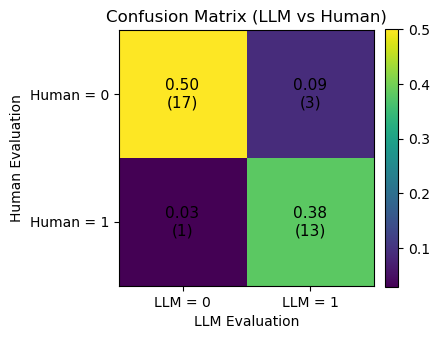

In [38]:
_ = plot_confusion_matrix_binary(human=human_eval, llm=np.array(vlm_eval) >= threshold)